Este notebook es el que usaremos para poder entrenar especificamente los modelos en base al dataset que vamos a usar que es el de libros, de este notebook van a salir las graficas que usaremos para el front end, y las funciones 

Nos vamos a centrar en completar una primera fase que seria preprocesar el dataset de libros:
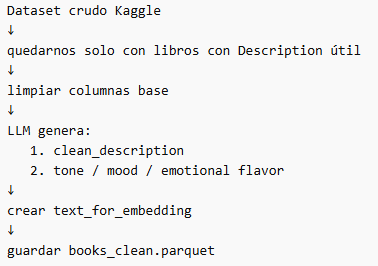

Para los embeddings vamos a juntar el titulo, la descripcion y la categoria, solo que en este caso usaremos una descripcion creada por un LLM mas limpia que la original y mas pequena, vamos a generar un Mood Label o Tone label tambien.

In [33]:
pip install kagglehub pandas numpy pyarrow tqdm openai tenacity -q

Note: you may need to restart the kernel to use updated packages.


Dataset que usaremos: https://www.kaggle.com/datasets/elvinrustam/books-dataset

# **Fase 1: Preprocessing de Dataset**

Bajamos el dataset de kaggle y definimos algunos imports

In [34]:
import os
import json
import glob
import re
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import kagglehub

DATASET_ID = "elvinrustam/books-dataset"

path = kagglehub.dataset_download(DATASET_ID)
print("Dataset path:", path)

files = glob.glob(os.path.join(path, "**", "*"), recursive=True)
for f in files[:30]:
    print(f)

Dataset path: C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3
C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDataset.csv
C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDatasetClean.csv


Crear el csv con el dataset que bajamos de kaggle, para este caso kaggle traia 2 uno clean y uno raw que son lo mismo en informacion solo que la fecha esta procesada diferente y el precio


In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import os
import json

dataset_path = Path(path)

clean_csv = dataset_path / "BooksDatasetClean.csv"

df_raw = pd.read_csv(clean_csv)

print("Using:", clean_csv)
print("Shape:", df_raw.shape)
df_raw.head()

Using: C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDatasetClean.csv
Shape: (103063, 8)


,Title,Authors,Description,Category,Publisher,Price Starting With ($),Publish Date (Month),Publish Date (Year)
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


Vamos a normalizar los nombres de las columnas para no tener espacios y mayusculas y no batallar 

In [36]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("$", "usd", regex=False)
)

print(df.columns.tolist())
df.head()

['title', 'authors', 'description', 'category', 'publisher', 'price_starting_with_usd', 'publish_date_month', 'publish_date_year']


,title,authors,description,category,publisher,price_starting_with_usd,publish_date_month,publish_date_year
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


Definimos las columnas principales, para tenerlas en variable

In [37]:
COL_TITLE = "title"
COL_AUTHORS = "authors"
COL_DESC = "description"
COL_CATEGORY = "category"
COL_PUBLISHER = "publisher"
COL_PRICE = "price_starting_with_usd"
COL_MONTH = "publish_date_month"
COL_YEAR = "publish_date_year"

Aqui vamos a implementar una limpieza basica del texto, quitar espacios repetidos, html, etc.

In [38]:
def clean_basic_text(x):
    if pd.isna(x):
        return ""
    
    x = str(x)
    x = re.sub(r"<.*?>", " ", x)          # quitar HTML
    x = re.sub(r"\s+", " ", x).strip()    # espacios repetidos
    return x

df["title_clean"] = df[COL_TITLE].apply(clean_basic_text)
df["authors_clean"] = df[COL_AUTHORS].apply(clean_basic_text)
df["description_original_clean"] = df[COL_DESC].apply(clean_basic_text)
df["category_clean"] = df[COL_CATEGORY].apply(clean_basic_text)
df["publisher_clean"] = df[COL_PUBLISHER].apply(clean_basic_text)

df[[
    "title_clean",
    "authors_clean",
    "description_original_clean",
    "category_clean",
    "publisher_clean"
]].head()

,title_clean,authors_clean,description_original_clean,category_clean,publisher_clean
0,Goat Brothers,"By Colton, Larry",,"History , General",Doubleday
1,The Missing Person,"By Grumbach, Doris",,"Fiction , General",Putnam Pub Group
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",,"Cooking , Reference",Workman Pub Co
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",,,Natl Pr Books
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",,,Amy Spangler


Ahora lo importante, vamos a solo quedarnos con libros que tienen una descripcion util, no nulos, no si no tienen nada, etc. Porque para este problema necesitamos que los libros tengan descripcion porque lo necesitamos para la core function de nuestro sistema, para que los embeddings tengan sentido, y a parte se las pasaremos a un LLM para que nos cree una descripcion mas limpia y compacta, y no le podemos pasar valores nulos.

In [39]:
# -----------------------------
# Required field validation
# -----------------------------

bad_required_patterns = [
    r"^\s*$",
    r"^null$",
    r"^none$",
    r"^nan$",
    r"^unknown$",
    r"^n/a$",
    r"^na$",
    r"not available"
]

bad_required_regex = re.compile("|".join(bad_required_patterns), re.IGNORECASE)

bad_description_patterns = [
    r"^\s*$",
    r"^null$",
    r"^none$",
    r"^nan$",
    r"^unknown$",
    r"^n/a$",
    r"^na$",
    r"for ingest only",
    r"description unavailable",
    r"no description",
    r"not available"
]

bad_description_regex = re.compile("|".join(bad_description_patterns), re.IGNORECASE)


def clean_category_text(x):
    x = clean_basic_text(x)
    x = re.sub(r"\s*,\s*", ", ", x)   # "Fiction , General" -> "Fiction, General"
    x = re.sub(r"\s+", " ", x).strip()
    return x


def is_valid_required_text(x):
    if not x:
        return False
    
    if bad_required_regex.search(x):
        return False
    
    return True


def is_valid_description(desc, min_chars=80):
    if not desc:
        return False
    
    if bad_description_regex.search(desc):
        return False
    
    if len(desc) < min_chars:
        return False
    
    alpha_count = sum(ch.isalpha() for ch in desc)
    if alpha_count < 40:
        return False
    
    return True


# Clean category format before filtering
df["category_clean"] = df["category_clean"].apply(clean_category_text)

before = len(df)

df = df[
    df["title_clean"].apply(is_valid_required_text) &
    df["category_clean"].apply(is_valid_required_text) &
    df["description_original_clean"].apply(is_valid_description)
].copy()

after = len(df)

print("Rows before filtering:", before)
print("Rows after filtering:", after)
print("Rows removed:", before - after)
print("Remaining percentage:", round(after / before * 100, 2), "%")

Rows before filtering: 103063
Rows after filtering: 64620
Rows removed: 38443
Remaining percentage: 62.7 %


Vamos a limpiar los libros que tengan datos como Unkown, para despues descartarlos tambien

In [40]:
# -----------------------------
# Optional metadata for frontend display
# -----------------------------

def display_value(x):
    if pd.isna(x):
        return ""
    
    x = str(x).strip()
    
    if x.lower() in ["", "nan", "none", "null", "unknown", "n/a", "na"]:
        return ""
    
    return x


df["authors_display"] = df["authors_clean"].apply(display_value)
df["publisher_display"] = df["publisher_clean"].apply(display_value)
df["price_display"] = df[COL_PRICE].apply(display_value)
df["publish_month_display"] = df[COL_MONTH].apply(display_value)
df["publish_year_display"] = df[COL_YEAR].apply(display_value)

df[[
    "title_clean",
    "authors_display",
    "category_clean",
    "publisher_display",
    "price_display",
    "publish_month_display",
    "publish_year_display"
]].head()

,title_clean,authors_display,category_clean,publisher_display,price_display,publish_month_display,publish_year_display
7,Journey Through Heartsongs,"By Stepanek, Mattie J. T.","Poetry, General",VSP Books,19.96,September,2001
8,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and Bouis, Antonina W.","Biography & Autobiography, General",Random House,4.99,June,1987
10,The Dieter's Guide to Weight Loss During Sex,"By Smith, Richard","Health & Fitness, Diet & Nutrition, Diets",Workman Publishing Company,4.99,January,1978
11,Germs : Biological Weapons and America's Secret War,"By Miller, Judith, Engelberg, Stephen, and Broad, William J.","Technology & Engineering, Military Science",Simon & Schuster,4.99,October,2001
13,The Good Book: Reading the Bible with Mind and Heart,"By Gomes, Peter J.","Religion, Biblical Biography, General",Harper Perennial,5.29,May,1998


Quitamos los registros que esten duplicados

In [42]:
before = len(df)

df = df.drop_duplicates(
    subset=["title_clean", "authors_clean", "description_original_clean"]
).reset_index(drop=True)

after = len(df)

print("Rows before duplicates:", before)
print("Rows after duplicates:", after)
print("Duplicates removed:", before - after)

Rows before duplicates: 64620
Rows after duplicates: 64243
Duplicates removed: 377


Hacemos un sanity check para ver que no tengamos registros malos o sin texto en los campos de Title, Description y Categories porque son los unicos 3 que importan para los embeddings, todos los demas pueden estar incompletos no importa mucho, solamente no van a salir en el Hover del mapa y ya.

In [47]:
print("Total rows after duplicates:", len(df))

print("Empty titles:", (df["title_clean"] == "").sum())
print("Empty categories:", (df["category_clean"] == "").sum())
print("Empty descriptions:", (df["description_original_clean"] == "").sum())

bad_values = ["unknown", "null", "none", "nan", "n/a", "na", ""]

print("Bad titles:", df["title_clean"].str.lower().isin(bad_values).sum())
print("Bad categories:", df["category_clean"].str.lower().isin(bad_values).sum())
print("Bad descriptions:", df["description_original_clean"].str.lower().isin(bad_values).sum())

Total rows after duplicates: 64243
Empty titles: 0
Empty categories: 0
Empty descriptions: 0
Bad titles: 0
Bad categories: 0
Bad descriptions: 0


Ahora si vamos a visualizar algunos ejemplos de descripciones para poder ver si son muy largas, o con que estamos trabajando, para ver si es necesario pasarselas a un LLM para que nos cree la version clean. 

In [43]:
pd.set_option("display.max_colwidth", 700)

sample = df[[
    "title_clean",
    "authors_clean",
    "category_clean",
    "description_original_clean"
]].sample(4, random_state=42)

sample

,title_clean,authors_clean,category_clean,description_original_clean
31256,"The Monitor: Civil War Battleship, Level 4","By Day, Larry (ILT) and Thompson, Gare","Juvenile Fiction, Readers, Beginner","The U.S.S. Monitor was an entirely new type of warship when it launched in 1862. Dubbed ""the forefather of the modern Navy,"" this ironclad ship changed how wars are fought at sea. But on New Year's Eve, 1862, it sank off the coast of North Carolina in a terrible storm. No one thought the Monitor could be raised, but after 140 years, parts of the ironclad have finally been brought to the surface. This book chronicles the Monitor's revolutionary design, exciting battle, and intriguing excavation.Illustrated by Larry Day."
7167,TV Guide: Fifty Years of Television,"By Lasswell, Mark","Performing Arts, Television, General","More than 350 full-color and black-and-white photographs from the archive of TV Guide celebrate a half century of television history, from The Howdy Doody Show and I Love Lucy to The Simpsons and The Sopranos, and the personalities, shows, and landmark events that changed entertainment history. 150,000 first printing."
53797,Moments of Peace in the Presence of God,By Baker Publishing Group,"Religion, Meditations","Wisdom and inspiration from the Psalms come to life anew in this collection of more than 170 meditations. Each two-page spread presents a devotional thought and encouraging Scriptures. The unique crafting and blending of words and illustrations ensures appeal to Christians young and old. Ideal for year-round gift-giving--including Mother's Day, Father's Day, and graduations."
60930,I Wish This War Were over,"By O'Hehir, Diana","Fiction, Literary","Nineteen-year-old Helen Reynolds, journeying cross-country by train as America enters World War II, meets and is bewitched by John O'Connell, a former suitor of her mother, the sad, beautiful, alcoholic Selma"


Si, definitivamente las descripciones son muy largas, necesitamos pasarselas a un LLM para que nos la normalize creandonos descripciones con un limite de palabras, compactas pero que aun asi capture la esencia del texto para que quede bien para los embeddings.

Vamos a ver la distribucion de las descripciones

In [44]:
df["description_length"] = df["description_original_clean"].str.len()

df["description_length"].describe()

count    64243.000000
mean       770.036922
std        654.561322
min         80.000000
25%        240.000000
50%        632.000000
75%       1091.000000
max      23502.000000
Name: description_length, dtype: float64

In [45]:
df[[
    "title_clean",
    "category_clean",
    "description_length",
    "description_original_clean"
]].sort_values("description_length").head(3)

,title_clean,category_clean,description_length,description_original_clean
25620,In God We Trust: A Positive Faith for Troubled Times,"Religion, Inspirational",80,"Relates ways of building a better, more positive life through the power of faith"
35371,First Words (Baby Genius),"Juvenile Nonfiction, Concepts, General",80,Book for young children increases vocabulary by associating words with pictures.
24611,Con Mi Hermano / With My Brother,"Juvenile Fiction, People & Places, United States, Hispanic & Latino",80,A little boy admires his big brother and aspires to be like him when he is older


In [46]:
df[[
    "title_clean",
    "category_clean",
    "description_length",
    "description_original_clean"
]].sort_values("description_length", ascending=False).head(3)

,title_clean,category_clean,description_length,description_original_clean
40253,Blood of Paradise,"Fiction, General",23502,"El Salvador: America’s great Cold War success story and the model for Iraq’s fledgling democracy–if one ignores the grinding poverty, the corruption, the spiraling crime, and a murder rate ranked near the top in the hemisphere. This is where Jude McManus works as an executive protection specialist, currently assigned to an American engineer working for a U.S. consortium.Ten years before, at age seventeen, he saw his father and two Chicago cop colleagues arrested for robbing street dealers. The family fell apart in the scandal’s wake, his disgraced dad died under suspicious circumstances, and Jude fled Chicago to join the army and forge a new life.Now the past returns when one of his fath..."
6113,The Sixteen Pleasures: A Novel,"Fiction, Historical, General",14977,"Chapter OneWhere I Want to BeI was twenty-nine years old when the Arno flooded its banks on Friday 4 November 1966. According to the Sunday New York Times the damage wasn't extensive, but by Monday it was clear that Florence was a disaster. Twenty feet of water in the cloisters of Santa Croce, the Cimabue crucifix ruined beyond hope of restoration, panels ripped from the Baptistry doors, the basement of the Biblioteca Nazionale completely underwater, hundreds of thousands of volumes waterlogged, the Archivio di Stato in total disarray. On Tuesday I decided to go to Italy, to offer my services as a humble book conservator, to help in any way I could, to save whatever could be saved, inclu..."
18356,An Accidental American: A Novel (Mortalis),"Fiction, Thrillers, General",12456,"Forced out of a self-imposed exile, one woman faces a lifetime’s worth of secrets and betrayal–all in the name of staying alive. Nicole Blake had planned to leave her criminal life in the past. She had done her time in a dank prison in Marseille and relinquished the world of forgery and counterfeiting for an unassuming career as a freelance consultant. Now her world is a small farm in the French Pyrenees, with daily fresh eggs and the companionship of her devoted dog.But when U.S. intelligence operative John Valsamis shows up at her door, Nicole is reminded that she’ll always be an ex-con. Valsamis is after Nicole’s former lover, Rahim Ali, and soon Nicole finds herself back in Lisbon, t..."


Guardamos el Processed dataset que tenemos, para pasar ahora a la siguiente fase

In [48]:
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

preprocessed_path = ARTIFACTS_DIR / "books_preprocessed_before_llm.parquet"

df.to_parquet(preprocessed_path, index=False)

print("Saved:", preprocessed_path)
print("Shape:", df.shape)

Saved: artifacts\books_preprocessed_before_llm.parquet
Shape: (64243, 19)


# **Fase 2: Usar LLM para generar mood label y una descripcion compacta que usaremos para Embeddings**

Cargamos el dataset preprocesado directamente del .parquet file que tenemos en artifacts

In [2]:
from pathlib import Path
import pandas as pd
import json
import os
from tqdm.auto import tqdm

ARTIFACTS_DIR = Path("artifacts")

df = pd.read_parquet(ARTIFACTS_DIR / "books_preprocessed_before_llm.parquet")

print(df.shape)
df.head(1)

(64243, 19)


,title,authors,description,category,publisher,price_starting_with_usd,publish_date_month,publish_date_year,title_clean,authors_clean,description_original_clean,category_clean,publisher_clean,authors_display,publisher_display,price_display,publish_month_display,publish_year_display,description_length
0,Journey Through Heartsongs,"By Stepanek, Mattie J. T.",Collects poems written by the eleven-year-old ...,"Poetry , General",VSP Books,19.96,September,2001,Journey Through Heartsongs,"By Stepanek, Mattie J. T.",Collects poems written by the eleven-year-old ...,"Poetry, General",VSP Books,"By Stepanek, Mattie J. T.",VSP Books,19.96,September,2001,176


Ahora vamos a definir los tone options que va a tener el LLM para elegir 


In [3]:
TONE_OPTIONS = [
    "Dark",
    "Suspenseful",
    "Mysterious",
    "Romantic",
    "Uplifting",
    "Reflective",
    "Melancholic",
    "Adventurous",
    "Humorous",
    "Whimsical",
    "Inspiring",
    "Informative",
    "Serious",
    "Emotional",
    "Neutral"
]

Ahora vamos a preprara el system y el prompt que le daremos a nuestro LLM para que nos genere primero Mood Labels y despues una descripcion clean y compacta con limite de palabras


In [28]:
pip install ollama tqdm -q

Note: you may need to restart the kernel to use updated packages.


Preparar para inferencia en labels

In [37]:
MODEL_NAME = "qwen2.5:7b-instruct"

test_rows = []

start_time = time.time()

for idx, row in tqdm(df_sample_10.iterrows(), total=len(df_sample_10)):
    try:
        result = ollama_clean_book(row, model_name=MODEL_NAME)

        test_rows.append({
            "model_name": MODEL_NAME,
            "row_index": int(idx),
            "title_clean": row["title_clean"],
            "category_clean": row["category_clean"],
            "description_original_clean": row["description_original_clean"],
            "clean_description": result.get("clean_description", ""),
            "tone_label": result.get("tone_label", ""),
            "error": ""
        })

    except Exception as e:
        test_rows.append({
            "model_name": MODEL_NAME,
            "row_index": int(idx),
            "title_clean": row["title_clean"],
            "category_clean": row["category_clean"],
            "description_original_clean": row["description_original_clean"],
            "clean_description": "",
            "tone_label": "",
            "error": str(e)
        })

elapsed = time.time() - start_time

df_qwen_test = pd.DataFrame(test_rows)

print(f"Finished {MODEL_NAME} in {elapsed:.2f} seconds")
print(f"Average seconds per book: {elapsed / len(df_sample_10):.2f}")

df_qwen_test[[
    "model_name",
    "title_clean",
    "category_clean",
    "clean_description",
    "tone_label",
    "error"
]]

100%|██████████| 50/50 [07:39<00:00,  9.18s/it]

Finished qwen2.5:7b-instruct in 459.13 seconds
Average seconds per book: 9.18


,model_name,title_clean,category_clean,clean_description,tone_label,error
0,qwen2.5:7b-instruct,"The Monitor: Civil War Battleship, Level 4","Juvenile Fiction, Readers, Beginner","The U.S.S. Monitor, a groundbreaking Civil War ironclad ship, fought bravely before sinking in a storm off North Carolina. Its discovery after 140 years offers insight into naval history.",Informative,
1,qwen2.5:7b-instruct,TV Guide: Fifty Years of Television,"Performing Arts, Television, General","TV Guide showcases 350 photos spanning 50 years of television history, highlighting iconic shows and personalities.",Informative,
2,qwen2.5:7b-instruct,Moments of Peace in the Presence of God,"Religion, Meditations",More than 170 meditations from the Psalms offer wisdom and inspiration in a blend of devotional thoughts and Scriptures.,Uplifting,
3,qwen2.5:7b-instruct,I Wish This War Were over,"Fiction, Literary","Nineteen-year-old Helen travels across America during World War II and falls for John, only to be reminded of her mother's tragic past.",Melancholic,
4,qwen2.5:7b-instruct,Take-Out City,"Fiction, Mystery & Detective, General","Catherine Dean, a caterer, returns home to find her apartment occupied by the mysterious Angela and her con man boyfriend, Bobby.",Mysterious,
5,qwen2.5:7b-instruct,National Geographic Photography Field Guides: Landscapes,"Photography, Techniques, General",Learn how to capture breathtaking landscapes like a National Geographic photographer in this comprehensive guide.,Informative,
6,qwen2.5:7b-instruct,Bhagavad-Gita As It Is,"Religion, Hinduism, Sacred Writings","A comprehensive edition of the Bhagavad-Gita, presenting India's Vedic wisdom.",Informative,
7,qwen2.5:7b-instruct,"Speaking of Inalienable Rights, Amy","Fiction, General","American, Samoan, and Vietnamese characters explore life's complexities through bicentennial-themed comic strips.",Humorous,
8,qwen2.5:7b-instruct,"A Manual for Writers of Term Papers, Theses, and Dissertations, 6th Edition (Chicago Guides to Writing, Editing, and Publishing)","Education, Teaching Methods & Materials, Arts & Humanities","A comprehensive guide for students writing term papers, theses, and dissertations, updated to include modern technology and citation methods.",Informative,
9,qwen2.5:7b-instruct,Pet Sitting for Profit: A Complete Manual for Professional Success,"Pets, Reference",A comprehensive guide for aspiring and established pet sitters on how to start or improve their business.,Informative,


Despues de muchas iteraciones nos dimos cuenta que no podemos usar LLM para generar una descripcion compacta, para los labels un modelo de 7b de parametros ya esta sufriendo mucho a comparacion con el de 14b y el de 14b y 20b de parametros toma de 20 a 40 segundos por libro. 

tomando el de 7b de parametros y un average de 10 segundos por libro, nos tomaria 150 horas en hacer todo el dataset, aproximadamente 6 dias completos corriendo el codigo entonces para el demo de ahorita esto no va a ser posible
 

# **Fase 3: Vectorizar dataset y hacer labels de polaridad con similitud semantica en high dimention**

**que vamos a hacer?**

Vamos a correr los embeddings en la descripcion original y tratar de sacar la polaridad tambien con embeddings

In [4]:
pip install sentence-transformers -q

Note: you may need to restart the kernel to use updated packages.


Celda para preparar el texto para los embeddings sin LLM

In [5]:
MAX_DESC_CHARS = 900 # TOMAMOS SOLO LAS PRIMERAS 130 A 150 PALABRAS DE LA DESCRIPCION

df["description_for_embedding"] = (
    df["description_original_clean"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, MAX_DESC_CHARS)
)

df["text_for_embedding"] = (
    "Title: " + df["title_clean"].fillna("").astype(str) + ". " +
    "Category: " + df["category_clean"].fillna("").astype(str) + ". " +
    "Description: " + df["description_for_embedding"].fillna("").astype(str)
)

df[[
    "title_clean",
    "category_clean",
    "description_for_embedding",
    "text_for_embedding"
]].head()

,title_clean,category_clean,description_for_embedding,text_for_embedding
0,Journey Through Heartsongs,"Poetry, General",Collects poems written by the eleven-year-old ...,Title: Journey Through Heartsongs. Category: P...
1,In Search of Melancholy Baby,"Biography & Autobiography, General",The Russian author offers an affectionate chro...,Title: In Search of Melancholy Baby. Category:...
2,The Dieter's Guide to Weight Loss During Sex,"Health & Fitness, Diet & Nutrition, Diets","A humor classic, this tongue-in-cheek diet pla...",Title: The Dieter's Guide to Weight Loss Durin...
3,Germs : Biological Weapons and America's Secre...,"Technology & Engineering, Military Science","Deadly germs sprayed in shopping malls, bomb-l...",Title: Germs : Biological Weapons and America'...
4,The Good Book: Reading the Bible with Mind and...,"Religion, Biblical Biography, General","""The Bible and the social and moral consequenc...",Title: The Good Book: Reading the Bible with M...


Estos serian los tonos y las palabras descriptivas que vamos a vectorizar, estos los vamos a comparar con cada libro y asignamos el tono mas cercano, esto corre muchisimo mas rapido que inferencia de LLM por 65k libros

In [6]:
TONE_PROTOTYPES = {
    "Dark": "bleak, grim, disturbing, violent, tragic, ominous, morally heavy, frightening",
    "Suspenseful": "tense, dangerous, uncertain, thrilling, full of secrets, risk, pursuit, investigation",
    "Mysterious": "enigmatic, puzzling, hidden truth, unexplained events, secrets, discovery",
    "Romantic": "love, attraction, relationships, intimacy, marriage, emotional connection",
    "Uplifting": "hopeful, encouraging, positive, inspiring, comforting, life-affirming",
    "Reflective": "thoughtful, introspective, philosophical, spiritual, contemplative, self-examining",
    "Melancholic": "sad, nostalgic, grief, loneliness, loss, regret, bittersweet",
    "Adventurous": "journey, exploration, quest, danger, action, travel, discovery",
    "Humorous": "funny, satirical, witty, playful, comedic, amusing",
    "Whimsical": "imaginative, quirky, magical, playful, fanciful, lighthearted",
    "Inspiring": "motivational, aspirational, achievement, resilience, personal growth",
    "Informative": "educational, factual, instructional, practical, explanatory, reference guide",
    "Serious": "formal, grave, political, historical, social issues, conflict, analytical",
    "Emotional": "deep feelings, family, relationships, trauma, healing, heartfelt, personal struggle",
    "Neutral": "general, balanced, descriptive, low emotional intensity"
}

Cargar el modelo de embeddings

In [7]:
from sentence_transformers import SentenceTransformer
import torch
import numpy as np
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(embedding_model_name, device=device)

Using device: cuda


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5703.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Con esta celda hacemos los embeddings del dataset que preparamos 


In [8]:
texts = df["text_for_embedding"].tolist()

book_embeddings = embedding_model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings shape:", book_embeddings.shape)

Batches: 100%|██████████| 251/251 [00:43<00:00,  5.70it/s]


Embeddings shape: (64243, 384)


Guardamos los embeddings para no tener que estar corriendo a cada rato la celda

In [9]:
np.save(ARTIFACTS_DIR / "book_embeddings.npy", book_embeddings)

df.to_parquet(ARTIFACTS_DIR / "books_with_text_for_embedding.parquet", index=False)
df.to_csv(ARTIFACTS_DIR / "books_with_text_for_embedding.csv", index=False)

print("Saved embeddings and dataframe.")

Saved embeddings and dataframe.


Vectorizamos la lista de tonos con su descripcion

In [10]:
tone_names = list(TONE_PROTOTYPES.keys())
tone_texts = [
    f"Tone: {tone}. Meaning: {description}"
    for tone, description in TONE_PROTOTYPES.items()
]

tone_embeddings = embedding_model.encode(
    tone_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Tone embeddings shape:", tone_embeddings.shape)

Batches: 100%|██████████| 1/1 [00:00<00:00, 64.53it/s]

Tone embeddings shape: (15, 384)


In [11]:
similarities = book_embeddings @ tone_embeddings.T

tone_indices = similarities.argmax(axis=1)
tone_scores = similarities.max(axis=1)

df["tone_label_approx"] = [tone_names[i] for i in tone_indices]
df["tone_score"] = tone_scores

df[[
    "title_clean",
    "category_clean",
    "description_for_embedding",
    "tone_label_approx",
    "tone_score"
]].head(20)

,title_clean,category_clean,description_for_embedding,tone_label_approx,tone_score
0,Journey Through Heartsongs,"Poetry, General",Collects poems written by the eleven-year-old ...,Uplifting,0.337724
1,In Search of Melancholy Baby,"Biography & Autobiography, General",The Russian author offers an affectionate chro...,Melancholic,0.359261
2,The Dieter's Guide to Weight Loss During Sex,"Health & Fitness, Diet & Nutrition, Diets","A humor classic, this tongue-in-cheek diet pla...",Humorous,0.240507
3,Germs : Biological Weapons and America's Secre...,"Technology & Engineering, Military Science","Deadly germs sprayed in shopping malls, bomb-l...",Mysterious,0.211088
4,The Good Book: Reading the Bible with Mind and...,"Religion, Biblical Biography, General","""The Bible and the social and moral consequenc...",Dark,0.290082
5,All over but the Shoutin',"Biography & Autobiography, Personal Memoirs",A New York Times Notable Book of the YearThis ...,Emotional,0.233746
6,Hill Rat: Blowing the Lid Off Congress,"Political Science, General",As a top aide to powerful Texas Congressman Ro...,Serious,0.137456
7,Personality of the Cat,"Pets, Cats, General",A delightful collection of reflections on the ...,Romantic,0.253456
8,Betrayal : How the Clinton Administration Unde...,"Political Science, General","Gertz, writer for the Moonie-influenced Washin...",Mysterious,0.305042
9,Shadow Song,"Fiction, General","It was a wonderful summer, a great memory, the...",Dark,0.275912


In [12]:
df.to_parquet(ARTIFACTS_DIR / "books_with_embeddings_and_tone_approx.parquet", index=False)
df.to_csv(ARTIFACTS_DIR / "books_with_embeddings_and_tone_approx.csv", index=False)

np.save(ARTIFACTS_DIR / "tone_embeddings.npy", tone_embeddings)

print("Saved tone approximation outputs.")

Saved tone approximation outputs.


Visualizamos la cantidad de embeddings y aproximadamente cuantos libros tienen ese label y el porcentaje que representa el label sobre todo el dataset

In [13]:
tone_distribution = (
    df["tone_label_approx"]
    .value_counts()
    .reset_index()
)

tone_distribution.columns = ["tone_label_approx", "count"]
tone_distribution["percentage"] = (
    tone_distribution["count"] / len(df) * 100
).round(2)

tone_distribution

,tone_label_approx,count,percentage
0,Dark,11886,18.50
1,Mysterious,8126,12.65
2,Emotional,8105,12.62
3,Inspiring,7634,11.88
4,Adventurous,6789,10.57
5,Informative,4875,7.59
6,Romantic,3351,5.22
7,Uplifting,2665,4.15
8,Serious,2308,3.59
9,Reflective,2282,3.55


Checamos la distribucion de los scores a travez de todo el dataset, un score mayor es mejor, menor es peor

In [14]:
df["tone_score"].describe()

count    64243.000000
mean         0.231065
std          0.076821
min         -0.043210
25%          0.178528
50%          0.228030
75%          0.280774
max          0.618880
Name: tone_score, dtype: float64

Tenemos una buena distribucion, tenemos un promedio de 0.23 para el score y un score de 0.20 - 0.35 es un tono aceptable/normal.

Vamos a checar los peores tonos

In [22]:
df[[
    "title_clean",
    "category_clean",
    "description_for_embedding",
    "tone_label_approx",
    "tone_score"
]].sort_values("tone_score").head(5)


,title_clean,category_clean,description_for_embedding,tone_label_approx,tone_score
55196,"Cook This, Not That! Easy & Awesome 350-Calorie Meals","Cooking, Health & Healing, Weight Control","Tired of always being too hungry (and tired!) to make smart food choices? Ever wonder why the less food you try to eat, the more fat you seem to gain? Ready to start enjoying all your favorite foods and never see an ounce of weight gain? Cook This, Not That! 350-Calorie Meals - by David Zinczenko with Matt Goulding - is the ultimate cookbook for people who love to eat-even if they don't love to cook. The authors of the best-selling diet and weight loss series Eat This, Not That! teach you how easy it is to turn the expensive and unhealthy foods in America's restaurants into fat-blasting superfoods that cost just pennies-and take just minutes to make! Can you believe... - At Olive Garden, an order of Chicken Parmigiana will cost you half a day's calories-and a day and a half's worth of sodium! Cook our Chicken Parm recipe at home and save 730 calories and $9.94! - At T.G.I.Friday's, a San",Humorous,-0.043210
24539,Inter-organizational Cooperation with SAP Solutions: Design and Management of Supply Networks (SAP Excellence),"Business & Economics, Management","Inter-organizational Cooperation with SAP Solutions - now in its second edition -describes the potential for cooperation in supply chain networks as well as the use of mySAP solutions in an inter-organizational context. The main focus is on applications from the fields of XML/EDI, data warehousing, supply chain management and electronic markets. On the basis of five case studies from the automotive industry, the use of mySAP solutions is demonstrated in practice. This second edition has been totally revised to take account of current challenges concerning building up cooperation from both the management and the software perspective. In order to achieve this, the author team was expanded.",Uplifting,-0.040394
5846,Controlling Cholesterol: Dr. Kenneth H. Cooper's Preventative Medicine Program,"Health & Fitness, Diet & Nutrition, Food Content Guides","Dr. Kenneth H. Cooper's all-new plan to lower cholesterol without drugs!The Old News: Elevated levels of cholesterol put you at risk for heart attack and stroke.The New News: Now you can control cholesterol naturally!Dr. Kenneth H. Cooper, a leading authority on controlling cholesterol, shares his all-new plan for balancing your blood lipids--without drugs and without side effects.Drawing on clinical trials and the most up-to-date medical research, Dr. Cooper explains how exciting new food discoveries can give you a revolutionary new way to manage your cholesterol. Inside you'll discover: How the new functional foods, such as Benecol and Take Control, can lower bad cholesterol while improving the ratio between good and bad cholesterol in only three weeks How these ""anti-cholesterol"" foods work, why they are safe to use, and who should use them How Dr. Cooper's approach can end--or greatl",Inspiring,-0.035939
13031,Rex Barney's Thank Youuuu for 50 Years in Baseball from Brooklyn to Baltimore,"Sports & Recreation, Baseball, General","September 26, 1981, millions of viewers watched on NBC television as Nolan Ryan pitched his fifth no-hitter. Late in the game, commentator Tony Kubek asked Joe Garagiola, ""Did you ever see anybody throw faster than Nolan Ryan?""Without hesitating, Joe replied, ""Sure. Rex Barney.""Joe Garagiola contributes the foreword for this story of Rex Barney, the man who threw faster than Feller, faster than Ryan; whose pitching career sped by quicker than his fastball because he could not control it. Barney became a legend as part of the most exciting era of the Brooklyn Dodgers - 1943 to 1951 - when Jackie Robinson came in and Leo Durocher switched to the hated New York Giants. Two months after Leo's departure, Barney no-hit the Giants in the Polo Grounds.In his own inimitable style, Rex tells the story of his battle to c

Y tambien vamos a checar los mejores tonos par aver que esta pasando

In [23]:
df[[
    "title_clean",
    "category_clean",
    "description_for_embedding",
    "tone_label_approx",
    "tone_score"
]].sort_values("tone_score", ascending=False).head(5)

,title_clean,category_clean,description_for_embedding,tone_label_approx,tone_score
33400,"Positive Words, Powerful Results: Simple Ways to Honor, Affirm, and Celebrate Life","Self-help, Motivational & Inspirational","Although we live in an ocean of words, we rarely acknowledge their power to uplift or put down, to inspire or discourage, to help or hurt. But in this jewel of a book, Hal Urban -- parent, award-winning teacher, and author of the classic Life's Greatest Lessons -- shows us simple and immediate ways that we can use language to change lives -- both our own and those around us.",Uplifting,0.618880
50152,"Faith, Hope, And Love: An Inspirational Treasury Of Quotations","Self-help, Personal Growth, General","These three simple virtues guide us in our relationships and give us strength, comfort, and inspiration. The profoundly beautiful sentiments expressed here will stimulate one's own personal reflections.",Uplifting,0.570456
18648,Emotionally Free : Letting Go of the Past to Live in the Moment,"Self-help, Personal Growth, Happiness","A guide to achieving personal fulfillment reveals how to overcome self-limiting doubts, guilt, and anger to gain emotional freedom and live more fully, honestly, and happily",Emotional,0.541110
5072,Writing the Modern Mystery (Genre Writing Series),"Language Arts & Disciplines, General","Describes the most popular styles of mysteries, discusses plotting, character development, and background, and tells how to prepare and submit a manuscript",Mysterious,0.540888
30127,Time for Joy: Daily Affirmations,"Self-help, Affirmations","Words can inspire, motivate and change us if we let them. Words can lift us to action. Words can move us to anger and rage or to love and tears. Most important, words can heal.May the words in this book be an inspiration for you when and as you need it. Read it by the page, one day at a time, or at random as you are so moved. Know that you are worthy of joy, that you deserve to have joy in your life. May you take this time to find joy and may you know peace and love.",Uplifting,0.535215


Posiblemente los peores tonos fue porque los libros son muy tecnicos y simplemente no encontro similitud con nada del diccionario JSON, lo cual es normal porque es un diccionario valga la redundancia corto, y no tenemos al LLM razonando el contexto entre tokens, pero se hace lo que se puede, la verdad para un promedio de 0.23 en score significa que los labels fueron asignados correctamente en su mayoria.

### **Ya tenemos Embeddings de todo el dataset y labels de tono por similitud semantica**

# Fase 3: aplicar UMAP para bajar la dimension de la vectorizacion y aplicar un algoritmo de clustering

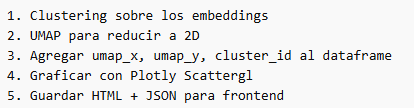

In [29]:
pip install umap-learn scikit-learn plotly joblib -q

Note: you may need to restart the kernel to use updated packages.


In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import time

ARTIFACTS_DIR = Path("artifacts")

df = pd.read_parquet(ARTIFACTS_DIR / "books_with_embeddings_and_tone_approx.parquet")
book_embeddings = np.load(ARTIFACTS_DIR / "book_embeddings.npy")

df["tone_label"] = df["tone_label_approx"]

print("DF shape:", df.shape)
print("Embeddings shape:", book_embeddings.shape)

DF shape: (64243, 24)
Embeddings shape: (64243, 384)


Vamos a aplicar UMAP 15D para el clustering, se baja primero a 15 dimensiones para no perder tanta dimension al apachurrar las dimensiones a solo 2, al aplicar clustering despues de un UMAP 2D puede que se vea mejor visualmente, pero puede perder mucha dimension, entonces optamos por UMAP 15D para no bajar de dimensiones tan abruptamente

In [41]:
import umap
import time

start_time = time.time()

umap_cluster_model = umap.UMAP(
    n_neighbors=30,
    n_components=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    low_memory=True
)

embedding_15d = umap_cluster_model.fit_transform(book_embeddings)

elapsed = time.time() - start_time

print("15D embedding shape:", embedding_15d.shape)
print(f"Finished UMAP 15D in {elapsed:.2f} seconds")

c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


15D embedding shape: (64243, 15)
Finished UMAP 15D in 52.86 seconds


Vamos a aplicar HDBSCAN clustering sobre las 15 Dimensiones que genero el UMAP

In [42]:
from sklearn.cluster import HDBSCAN
import time

start_time = time.time()

cluster_model = HDBSCAN(
    min_cluster_size=120,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    n_jobs=-1
)

cluster_labels = cluster_model.fit_predict(embedding_15d)

elapsed = time.time() - start_time

df["cluster_id"] = cluster_labels

print(f"Finished HDBSCAN in {elapsed:.2f} seconds")
print("Number of clusters:", len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))
print("Noise points:", (cluster_labels == -1).sum())
print("Noise percentage:", round((cluster_labels == -1).mean() * 100, 2), "%")

df["cluster_id"].value_counts().head(20)

c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Finished HDBSCAN in 26.96 seconds
Number of clusters: 69
Noise points: 27043
Noise percentage: 42.09 %


cluster_id
-1     27043
 20     4503
 35     3622
 57     2723
 31     1461
 54     1337
 60     1211
 52     1171
 25     1134
 28     1082
 9       969
 0       915
 53      697
 32      648
 7       641
 55      535
 49      527
 26      526
 63      522
 68      517
Name: count, dtype: int64

Revisamos los clusters

In [43]:
cluster_sizes = (
    df["cluster_id"]
    .value_counts()
    .reset_index()
)

cluster_sizes.columns = ["cluster_id", "count"]
cluster_sizes = cluster_sizes.sort_values("count", ascending=False)

cluster_sizes.head(30)

,cluster_id,count
0,-1,27043
1,20,4503
2,35,3622
3,57,2723
4,31,1461
5,54,1337
6,60,1211
7,52,1171
8,25,1134
9,28,1082


usaremos UMAP 2D para bajar las dimensinoes a 2 y poder graficar el mapa visual:

In [44]:
import time
import umap

start_time = time.time()

umap_2d_model = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.05,
    metric="cosine",
    random_state=42,
    low_memory=True
)

umap_coords = umap_2d_model.fit_transform(book_embeddings)

elapsed = time.time() - start_time

df["umap_x"] = umap_coords[:, 0]
df["umap_y"] = umap_coords[:, 1]

print("UMAP 2D shape:", umap_coords.shape)
print(f"Finished UMAP 2D in {elapsed:.2f} seconds")

df[[
    "title_clean",
    "category_clean",
    "cluster_id",
    "tone_label",
    "umap_x",
    "umap_y"
]].head()

c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (64243, 2)
Finished UMAP 2D in 37.11 seconds


,title_clean,category_clean,cluster_id,tone_label,umap_x,umap_y
0,Journey Through Heartsongs,"Poetry, General",-1,Uplifting,8.547768,9.469107
1,In Search of Melancholy Baby,"Biography & Autobiography, General",62,Melancholic,12.567510,9.964179
2,The Dieter's Guide to Weight Loss During Sex,"Health & Fitness, Diet & Nutrition, Diets",20,Humorous,3.626601,8.678993
3,Germs : Biological Weapons and America's Secret War,"Technology & Engineering, Military Science",-1,Mysterious,12.368091,9.918719
4,The Good Book: Reading the Bible with Mind and Heart,"Religion, Biblical Biography, General",35,Dark,9.045967,8.325946


Crear dataframe solo para graficar **sin el ruido**: 

Tambien se samplean solo 500 puntos por cluster

In [50]:
MAX_BOOKS_PER_CLUSTER = 500

df_map = df[df["cluster_id"] != -1].copy()

df_map_parts = []

for cluster_id, group in df_map.groupby("cluster_id"):
    n = min(len(group), MAX_BOOKS_PER_CLUSTER)
    df_map_parts.append(group.sample(n=n, random_state=42))

df_map = pd.concat(df_map_parts, axis=0).reset_index(drop=True)

print("Full dataset:", df.shape)
print("Map dataset:", df_map.shape)
print("Clusters in map:", df_map["cluster_id"].nunique())
print("Noise in map:", (df_map["cluster_id"] == -1).sum())

df_map[
    [
        "title_clean",
        "category_clean",
        "cluster_id",
        "tone_label",
        "umap_x",
        "umap_y",
    ]
].head()

Full dataset: (64243, 27)
Map dataset: (21953, 27)
Clusters in map: 69
Noise in map: 0


,title_clean,category_clean,cluster_id,tone_label,umap_x,umap_y
0,The Baseball I.Q. Challenge,"Sports & Recreation, Baseball, General",0,Adventurous,12.224864,3.823130
1,The Complete Book of Coaching Youth Soccer,"Sports & Recreation, Soccer",0,Inspiring,11.844674,4.016219
2,Summer Sports (The World of Sports),"Juvenile Nonfiction, General",0,Adventurous,11.891563,4.074765
3,The Blind Side: Evolution of a Game,"Sports & Recreation, Football",0,Inspiring,12.073984,4.203130
4,The Basket Counts (Matt Christopher Sports Classics),"Juvenile Fiction, Sports & Recreation, Basketball",0,Melancholic,12.035345,4.109434


Guardar artefactos para la grafica con Plotly para el frontend

In [51]:
import joblib

In [52]:
np.save(ARTIFACTS_DIR / "embedding_15d_for_clustering.npy", embedding_15d)
np.save(ARTIFACTS_DIR / "umap_coordinates.npy", umap_coords)

joblib.dump(umap_cluster_model, ARTIFACTS_DIR / "umap_15d_cluster_model.joblib")
joblib.dump(umap_2d_model, ARTIFACTS_DIR / "umap_2d_model.joblib")
joblib.dump(cluster_model, ARTIFACTS_DIR / "hdbscan_cluster_model.joblib")

df.to_parquet(ARTIFACTS_DIR / "books_with_hdbscan_clusters_umap_tone.parquet", index=False)
df_map.to_parquet(ARTIFACTS_DIR / "book_map_sample.parquet", index=False)

print("Saved UMAP + HDBSCAN artifacts.")
print("Full df:", df.shape)
print("Map df:", df_map.shape)

Saved UMAP + HDBSCAN artifacts.
Full df: (64243, 27)
Map df: (21953, 27)


Antes de graficar hay que recapicular un poco sobre los archivos que tenemos hasta ahorita

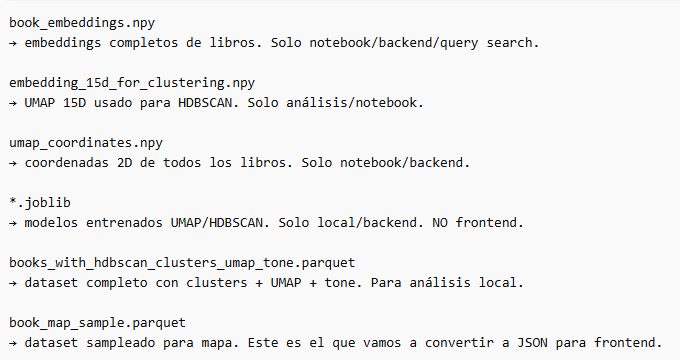

# Fase 4: Crear JSON para frontend

Este es para el mapa y la grafica el book_map_points.json

In [71]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import colorsys

ARTIFACTS_DIR = Path("artifacts")
FRONTEND_DIR = Path("frontend_data")
FRONTEND_DIR.mkdir(exist_ok=True)

df_map = pd.read_parquet(ARTIFACTS_DIR / "book_map_sample.parquet")

frontend_cols = [
    "title_clean",
    "authors_clean",
    "category_clean",
    "publisher_clean",
    "description_for_embedding",
    "tone_label",
    "tone_score",
    "cluster_id",
    "umap_x",
    "umap_y"
]

available_cols = [c for c in frontend_cols if c in df_map.columns]

book_map_points = df_map[available_cols].copy()

book_map_points = book_map_points.rename(columns={
    "title_clean": "title",
    "authors_clean": "authors",
    "category_clean": "category",
    "publisher_clean": "publisher",
    "description_for_embedding": "description",
    "tone_label": "tone",
    "tone_score": "tone_score",
    "cluster_id": "cluster_id",
    "umap_x": "x",
    "umap_y": "y"
})

book_map_points["id"] = book_map_points.index

CAP_PER_CLUSTER = 500

key_cols = [c for c in ["title", "authors", "category"] if c in book_map_points.columns]

if key_cols:
    book_map_points["_rank_key"] = pd.util.hash_pandas_object(
        book_map_points[key_cols].fillna("").astype(str),
        index=False
    ).astype("uint64")
else:
    book_map_points["_rank_key"] = np.arange(len(book_map_points))

book_map_points = book_map_points.sort_values(["cluster_id", "_rank_key"]).copy()

book_map_points["cluster_rank"] = (
    book_map_points
    .groupby("cluster_id")
    .cumcount()
    .add(1)
)

book_map_points = book_map_points[
    book_map_points["cluster_rank"] <= CAP_PER_CLUSTER
].copy()

book_map_points = book_map_points.drop(columns=["_rank_key"])


# ============================================================
# PALETA CATEGÓRICA PARA CLUSTERS
# ============================================================

def generate_cluster_palette(cluster_ids):
    cluster_ids = sorted(cluster_ids)
    colors = {}

    for idx, cluster_id in enumerate(cluster_ids):
        # Golden ratio para separar los tonos visualmente
        hue = (idx * 0.618033988749895) % 1.0

        # Variamos saturación y luminosidad para evitar colores demasiado parecidos
        saturation = 0.62 + 0.24 * ((idx % 3) / 2)
        lightness = 0.42 + 0.20 * ((idx % 4) / 3)

        r, g, b = colorsys.hls_to_rgb(hue, lightness, saturation)

        colors[int(cluster_id)] = "#{:02x}{:02x}{:02x}".format(
            int(r * 255),
            int(g * 255),
            int(b * 255)
        )

    return colors


cluster_ids = book_map_points["cluster_id"].dropna().astype(int).unique()
cluster_color_map = generate_cluster_palette(cluster_ids)

book_map_points["cluster_color"] = (
    book_map_points["cluster_id"]
    .astype(int)
    .map(cluster_color_map)
)


json_path = FRONTEND_DIR / "book_map_points.json"

book_map_points.to_json(
    json_path,
    orient="records",
    force_ascii=False
)

print("Saved:", json_path)
print("Shape:", book_map_points.shape)
print("Columns:", book_map_points.columns.tolist())

book_map_points.head(2)

Saved: frontend_data\book_map_points.json
Shape: (21953, 13)
Columns: ['title', 'authors', 'category', 'publisher', 'description', 'tone', 'tone_score', 'cluster_id', 'x', 'y', 'id', 'cluster_rank', 'cluster_color']


,title,authors,category,publisher,description,tone,tone_score,cluster_id,x,y,id,cluster_rank,cluster_color
450,The Chronicle Of Baseball: A Century of Major League Action,"By Mehno, John","Sports & Recreation, Baseball, History",Carlton Books Ltd,"This celebration of a century of the sport chronicles each year of baseball'shistory, covering every major event, and includes a special section on the 40greatest baseball players of all time. 900 photos, 500 in color.",Suspenseful,0.191021,0,12.222265,3.834611,450,1,#ad2828
449,20th Century Baseball Chronicle,"By Hanks, Stephen","Sports & Recreation, Baseball, History",Crescent,"Follows ninety years of the history of America's favorite game with statistics on key players and games and an overview of each year, and discusses individual players, pennant races, league championship series, and World Series games",Suspenseful,0.138788,0,12.245600,3.813696,449,2,#ad2828


Este es el cluster_summary.json y sirve para algun sidebar filtro o cards de cluster que quieran hacer en el frontend

Basicamente es como un mini resumen de todos los clusters de manera individual

In [77]:
def clean_value(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["", "nan", "none", "null", "unknown", "n/a", "na"]:
        return ""
    return x


def most_common(series):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.str.lower().isin(["", "nan", "none", "null", "unknown", "n/a", "na"])]

    if len(s) == 0:
        return ""

    return s.value_counts().index[0]


def top_counts(series, n=3):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.str.lower().isin(["", "nan", "none", "null", "unknown", "n/a", "na"])]

    total = len(s)

    if total == 0:
        return []

    counts = s.value_counts().head(n)

    return [
        {
            "label": str(label),
            "count": int(count),
            "percent": round((int(count) / total) * 100, 1)
        }
        for label, count in counts.items()
    ]


cluster_summary = (
    book_map_points
    .groupby("cluster_id")
    .agg(
        count=("id", "count"),
        top_tone=("tone", most_common),
        top_category=("category", most_common),
        example_title=("title", "first"),
        cluster_color=("cluster_color", "first"),
        tone_composition=("tone", top_counts),
        category_composition=("category", top_counts)
    )
    .reset_index()
    .sort_values("count", ascending=False)
)


def short_category_name(category):
    category = clean_value(category)

    if not category:
        return "Mixed Books"

    return category.split(",")[0].strip()


cluster_summary["cluster_name"] = cluster_summary.apply(
    lambda row: (
        f"{short_category_name(row['top_category'])} · {row['top_tone']}"
        if clean_value(row["top_tone"])
        else short_category_name(row["top_category"])
    ),
    axis=1
)

cluster_summary_path = FRONTEND_DIR / "cluster_summary.json"

cluster_summary.to_json(
    cluster_summary_path,
    orient="records",
    force_ascii=False
)

print("Saved:", cluster_summary_path)
cluster_summary.head()

Saved: frontend_data\cluster_summary.json


,cluster_id,count,top_tone,top_category,example_title,cluster_color,tone_composition,category_composition,cluster_name
0,0,500,Inspiring,"Sports & Recreation, Baseball, General",The Chronicle Of Baseball: A Century of Major League Action,#ad2828,"[{'label': 'Inspiring', 'count': 169, 'percent': 33.8}, {'label': 'Emotional', 'count': 117, 'percent': 23.4}, {'label': 'Informative', 'count': 68, 'percent': 13.6}]","[{'label': 'Sports & Recreation, Baseball, General', 'count': 48, 'percent': 9.6}, {'label': 'Sports & Recreation, Baseball, History', 'count': 45, 'percent': 9.0}, {'label': 'Sports & Recreation, General', 'count': 31, 'percent': 6.2}]",Sports & Recreation · Inspiring
31,31,500,Emotional,"Family & Relationships, Parenting, General","The Everything Parent's Guide To Raising Girls: A Complete Handbook to Develop Confidence, Promote Self-Esteem and Improve Communication",#e5df56,"[{'label': 'Emotional', 'count': 330, 'percent': 66.0}, {'label': 'Inspiring', 'count': 100, 'percent': 20.0}, {'label': 'Uplifting', 'count': 18, 'percent': 3.6}]","[{'label': 'Family & Relationships, Parenting, General', 'count': 127, 'percent': 25.4}, {'label': 'Family & Relationships, Parenting, Motherhood', 'count': 27, 'percent': 5.4}, {'label': 'Family & Relationships, Parenting, Fatherhood', 'count': 17, 'percent': 3.4}]",Family & Relationships · Emotional
20,20,500,Inspiring,"Cooking, General","Handbook of Eating Disorders: Psychology, Physiology, And Treatment",#0ec72d,"[{'label': 'Inspiring', 'count': 105, 'percent': 21.0}, {'label': 'Informative', 'count': 94, 'percent': 18.8}, {'label': 'Emotional', 'count': 78, 'percent': 15.6}]","[{'label': 'Cooking, General', 'count': 45, 'percent': 9.0}, {'label': 'Health & Fitness, Diet & Nutrition, Diets', 'count': 29, 'percent': 5.8}, {'label': 'Cooking, Reference', 'count': 26, 'percent': 5.2}]",Cooking · Inspiring
9,9,500,Informative,"House & Home, Decorating",Tiling,#2f8fc9,"[{'label': 'Informative', 'count': 171, 'percent': 34.2}, {'label': 'Reflective', 'count': 96, 'percent': 19.2}, {'label': 'Inspiring', 'count': 77, 'percent': 15.4}]","[{'label': 'House & Home, Decorating', 'count': 79, 'percent': 15.8}, {'label': 'House & Home, General', 'count': 41, 'percent': 8.2}, {'label': 'House & Home, Do-It-Yourself, General', 'count': 37, 'percent': 7.4}]",House & Home · Informative
7,7,500,Informative,"Gardening, General",Flowering Bulbs Indoors and Out,#5ce556,"[{'label': 'Informative', 'count': 148, 'percent': 29.6}, {'label': 'Adventurous', 'count': 110, 'percent': 22.0}, {'label': 'Inspiring', 'count': 97, 'percent': 19.4}]","[{'label': 'Gardening, General', 'count': 180, 'percent': 36.0}, {'label': 'Gardening, Flowers, Perennials', 'count': 23, 'percent': 4.6}, {'label': 'Gardening, Landscape', 'count': 21, 'percent': 4.2}]",Gardening · Informative


# Fase 5: Darle nombre a los clusters usando un LLM 

Esto se hace para poder darle nombre o label a los clusters ya que ahorita solo estan por ID, esto nos va a poder permitir mostrar los titulos en el mismo scatter map y generar una visualizacion parecida a la que nos recomendo el profesor:

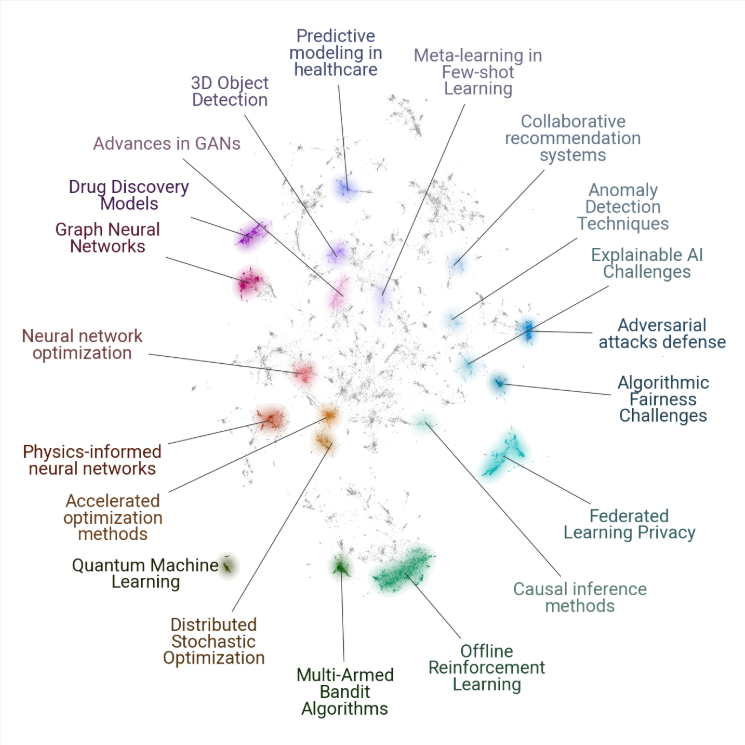

In [93]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import time
import re
import ollama

FRONTEND_DIR = Path("frontend_data")

points_path = FRONTEND_DIR / "book_map_points.json"
summary_path = FRONTEND_DIR / "cluster_summary.json"

df_points = pd.read_json(points_path)
df_summary = pd.read_json(summary_path)

print("Points:", df_points.shape)
print("Summary:", df_summary.shape)

df_summary.head(2)

Points: (21953, 13)
Summary: (69, 9)


,cluster_id,count,top_tone,top_category,example_title,cluster_color,tone_composition,category_composition,cluster_name
0,0,500,Inspiring,"Sports & Recreation, Baseball, General",The Chronicle Of Baseball: A Century of Major League Action,#ad2828,"[{'label': 'Inspiring', 'count': 169, 'percent': 33.8}, {'label': 'Emotional', 'count': 117, 'percent': 23.4}, {'label': 'Informative', 'count': 68, 'percent': 13.6}]","[{'label': 'Sports & Recreation, Baseball, General', 'count': 48, 'percent': 9.6}, {'label': 'Sports & Recreation, Baseball, History', 'count': 45, 'percent': 9.0}, {'label': 'Sports & Recreation, General', 'count': 31, 'percent': 6.2}]",Sports & Recreation · Inspiring
1,31,500,Emotional,"Family & Relationships, Parenting, General","The Everything Parent's Guide To Raising Girls: A Complete Handbook to Develop Confidence, Promote Self-Esteem and Improve Communication",#e5df56,"[{'label': 'Emotional', 'count': 330, 'percent': 66.0}, {'label': 'Inspiring', 'count': 100, 'percent': 20.0}, {'label': 'Uplifting', 'count': 18, 'percent': 3.6}]","[{'label': 'Family & Relationships, Parenting, General', 'count': 127, 'percent': 25.4}, {'label': 'Family & Relationships, Parenting, Motherhood', 'count': 27, 'percent': 5.4}, {'label': 'Family & Relationships, Parenting, Fatherhood', 'count': 17, 'percent': 3.4}]",Family & Relationships · Emotional


Funciones Helper

In [95]:
def clean_value(x):
    if pd.isna(x):
        return ""
    
    x = str(x).strip()
    
    if x.lower() in ["", "nan", "none", "null", "unknown", "n/a", "na"]:
        return ""
    
    return x


def truncate_text(text, max_chars=130):
    text = clean_value(text)
    
    if len(text) <= max_chars:
        return text
    
    return text[:max_chars].rsplit(" ", 1)[0] + "..."


def top_counts_for_prompt(series, n=5):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.str.lower().isin(["", "nan", "none", "null", "unknown", "n/a", "na"])]

    total = len(s)
    
    if total == 0:
        return []

    counts = s.value_counts().head(n)

    return [
        {
            "label": str(label),
            "percent": round((int(count) / total) * 100, 1)
        }
        for label, count in counts.items()
    ]


def get_representative_books(cluster_df, n_central=6, n_diverse=3):
    cluster_df = cluster_df.copy()

    cx = cluster_df["x"].median()
    cy = cluster_df["y"].median()

    cluster_df["_dist_to_center"] = np.sqrt(
        (cluster_df["x"] - cx) ** 2 + (cluster_df["y"] - cy) ** 2
    )

    central = cluster_df.sort_values("_dist_to_center").head(n_central)

    diverse_parts = []

    if "category" in cluster_df.columns:
        for _, group in cluster_df.groupby("category", dropna=True):
            if len(group) > 0:
                diverse_parts.append(group.sort_values("_dist_to_center").head(1))

    if diverse_parts:
        diverse = (
            pd.concat(diverse_parts)
            .drop_duplicates(subset=["id"])
            .sort_values("_dist_to_center")
            .head(n_diverse)
        )
    else:
        diverse = cluster_df.sort_values("_dist_to_center").head(n_diverse)

    reps = (
        pd.concat([central, diverse])
        .drop_duplicates(subset=["id"])
        .sort_values("_dist_to_center")
        .head(n_central + n_diverse)
    )

    books = []

    for _, row in reps.iterrows():
        books.append({
            "title": clean_value(row.get("title", "")),
            "category": clean_value(row.get("category", "")),
            "tone": clean_value(row.get("tone", "")),
            "description": truncate_text(row.get("description", ""), 130)
        })

    return books

Crear datos para el LLM para que en ellos se base a elegir la informacion del cluster:

In [96]:
cluster_prompt_records = []

for cluster_id, cluster_df in df_points.groupby("cluster_id"):
    cluster_id = int(cluster_id)

    top_categories = top_counts_for_prompt(cluster_df["category"], n=5)
    top_tones = top_counts_for_prompt(cluster_df["tone"], n=5)

    representative_books = get_representative_books(
        cluster_df,
        n_central=6,
        n_diverse=3
    )

    cluster_prompt_records.append({
        "cluster_id": cluster_id,
        "count": int(len(cluster_df)),
        "top_categories": top_categories,
        "top_tones": top_tones,
        "representative_books": representative_books
    })

cluster_prompt_records = sorted(cluster_prompt_records, key=lambda x: x["cluster_id"])

prompt_data_path = FRONTEND_DIR / "cluster_prompt_data_compact.json"

prompt_data_path.write_text(
    json.dumps(cluster_prompt_records, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Saved:", prompt_data_path)
print("Clusters:", len(cluster_prompt_records))

cluster_prompt_records[0]

Saved: frontend_data\cluster_prompt_data_compact.json
Clusters: 69


{'cluster_id': 0,
 'count': 500,
 'top_categories': [{'label': 'Sports & Recreation, Baseball, General',
   'percent': 9.6},
  {'label': 'Sports & Recreation, Baseball, History', 'percent': 9.0},
  {'label': 'Sports & Recreation, General', 'percent': 6.2},
  {'label': 'Sports & Recreation, Baseball, Essays & Writings',
   'percent': 5.0},
  {'label': 'Sports & Recreation, Basketball', 'percent': 4.6}],
 'top_tones': [{'label': 'Inspiring', 'percent': 33.8},
  {'label': 'Emotional', 'percent': 23.4},
  {'label': 'Informative', 'percent': 13.6},
  {'label': 'Uplifting', 'percent': 6.8},
  {'label': 'Humorous', 'percent': 4.6}],
 'representative_books': [{'title': "And Nobody Got Hurt 2!: The World's Weirdest, Wackiest, Most Amazing True Sports Stories",
   'category': 'Juvenile Nonfiction, Sports & Recreation, General',
   'tone': 'Mysterious',
   'description': 'An Olympian who sacrificed a medal to save a competitor, a professional soccer player who was bribed out of retirement with...

Preparamos el modelo usando OLLAMA usare qwen de 7 billones de parametros

In [101]:
MODEL_NAME = "qwen2.5:7b-instruct"

SYSTEM_PROMPT = """
You label semantic clusters for an AI Book Explorer map.

Return valid JSON only.

Create a concise English name for each book cluster.

Rules:
- cluster_name: 2 to 5 words, Title Case.
- short_label: 1 to 3 words, Title Case, useful for map labels.
- cluster_description: one short sentence, max 22 words.
- Do not use only a tone word as the name.
- Do not write "Cluster" in the name.
- Focus on topic, genre, audience, or semantic theme.

Good examples:
- Children's Animal Adventures
- Romantic Suspense Fiction
- Baseball Coaching Guides
- Christian Devotional Reading
- Practical Home Improvement
- Quick Family Cooking
"""


def build_cluster_user_prompt(record):
    lines = []

    lines.append(f"Cluster ID: {record['cluster_id']}")
    lines.append(f"Sample size: {record['count']}")
    lines.append("")

    lines.append("Top categories:")
    for item in record["top_categories"]:
        lines.append(f"- {item['label']} ({item['percent']}%)")

    lines.append("")
    lines.append("Top tones:")
    for item in record["top_tones"]:
        lines.append(f"- {item['label']} ({item['percent']}%)")

    lines.append("")
    lines.append("Representative books:")
    for i, book in enumerate(record["representative_books"], start=1):
        title = book.get("title", "")
        category = book.get("category", "")
        tone = book.get("tone", "")
        description = book.get("description", "")

        lines.append(f"{i}. {title}")
        
        if category:
            lines.append(f"   Category: {category}")
        
        if tone:
            lines.append(f"   Tone: {tone}")
        
        if description:
            lines.append(f"   Description: {description}")

    lines.append("")
    lines.append("""
Return exactly this JSON schema:

{
  "cluster_id": 0,
  "cluster_name": "Short Human Name",
  "short_label": "Short Label",
  "cluster_description": "One short sentence describing the cluster."
}
""")

    return "\n".join(lines)


def extract_json_object(text):
    text = text.strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)

    if not match:
        raise ValueError("No JSON object found in model response.")

    return json.loads(match.group(0))


def call_ollama_for_cluster(record, model_name=MODEL_NAME, temperature=0.1):
    response = ollama.chat(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": build_cluster_user_prompt(record)
            }
        ],
        format="json",
        options={
            "temperature": temperature,
            "num_ctx": 2048,
            "num_predict": 180
        }
    )

    content = response["message"]["content"]
    parsed = extract_json_object(content)

    parsed["cluster_id"] = int(record["cluster_id"])

    return {
        "cluster_id": int(parsed.get("cluster_id", record["cluster_id"])),
        "cluster_name": clean_value(parsed.get("cluster_name", "")),
        "short_label": clean_value(parsed.get("short_label", "")),
        "cluster_description": clean_value(parsed.get("cluster_description", ""))
    }

Ahora si darle inferencia bien al modelo en todo los clusters

In [103]:
labels_jsonl_path = FRONTEND_DIR / "cluster_llm_labels_raw.jsonl"
labels_json_path = FRONTEND_DIR / "cluster_llm_labels.json"

existing = {}

if labels_jsonl_path.exists():
    with labels_jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            existing[int(item["cluster_id"])] = item

print("Already labeled:", len(existing))

all_outputs = dict(existing)

for idx, record in enumerate(cluster_prompt_records, start=1):
    cluster_id = int(record["cluster_id"])

    if cluster_id in all_outputs:
        continue

    print(f"[{idx}/{len(cluster_prompt_records)}] Labeling cluster {cluster_id}...")

    try:
        output = call_ollama_for_cluster(record)

        all_outputs[cluster_id] = output

        with labels_jsonl_path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(output, ensure_ascii=False) + "\n")

        print("  ->", output.get("cluster_name", ""))

        time.sleep(0.2)

    except Exception as e:
        print(f"ERROR on cluster {cluster_id}: {e}")
        break

final_labels = [all_outputs[k] for k in sorted(all_outputs.keys())]

labels_json_path.write_text(
    json.dumps(final_labels, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Saved:", labels_json_path)
print("Total labels:", len(final_labels))

pd.DataFrame(final_labels).head()

Already labeled: 0
[1/69] Labeling cluster 0...
  -> Baseball and Sports Adventures
[2/69] Labeling cluster 1...
  -> Golf Adventures and Insights
[3/69] Labeling cluster 2...
  -> Inspiring Life Stories
[4/69] Labeling cluster 3...
  -> Contemporary Romance and Mystery
[5/69] Labeling cluster 4...
  -> Antiques & Collectibles Adventures
[6/69] Labeling cluster 5...
  -> Environmental Policy & Conservation
[7/69] Labeling cluster 6...
  -> Crafts & Sewing Adventures
[8/69] Labeling cluster 7...
  -> Gardening and Landscaping
[9/69] Labeling cluster 8...
  -> Creative Handcrafts
[10/69] Labeling cluster 9...
  -> Home Improvement & Design
[11/69] Labeling cluster 10...
  -> Ancient Mysteries and Thrills
[12/69] Labeling cluster 11...
  -> Beauty & Wellness Tips
[13/69] Labeling cluster 12...
  -> Dinosaur Mysteries and Adventures
[14/69] Labeling cluster 13...
  -> Shakespearean Dramas and Study Guides
[15/69] Labeling cluster 14...
  -> Classical Music Exploration
[16/69] Labeling clus

,cluster_id,cluster_name,short_label,cluster_description
0,0,Baseball and Sports Adventures,Sports Tales,"Inspiring, humorous stories about baseball and other sports adventures."
1,1,Golf Adventures and Insights,Golf Reads,"Engaging stories, tips, and adventures in the world of golf."
2,2,Inspiring Life Stories,Uplifting Tales,Heartwarming and motivational stories for personal growth and inspiration.
3,3,Contemporary Romance and Mystery,Romance & Mystery,Contemporary romance with elements of mystery and dark themes.
4,4,Antiques & Collectibles Adventures,Antique Adventures,"Explore the world of antiques and collectibles through mysterious, adventurous, and informative guides."


In [106]:
labels_path = FRONTEND_DIR / "cluster_llm_labels_minimal.json"

df_labels = pd.read_json(labels_path)

df_summary = pd.read_json(FRONTEND_DIR / "cluster_summary.json")

cols_to_replace = [
    "cluster_name",
    "short_label",
    "cluster_description",
    "keywords",
    "confidence"
]

df_summary_clean = df_summary.drop(
    columns=[c for c in cols_to_replace if c in df_summary.columns],
    errors="ignore"
)

df_summary_labeled = df_summary_clean.merge(
    df_labels[
        [
            "cluster_id",
            "cluster_name",
            "short_label",
            "cluster_description"
        ]
    ],
    on="cluster_id",
    how="left"
)

fallback_name = (
    df_summary_labeled["top_category"].astype(str).str.split(",").str[0]
    + " · "
    + df_summary_labeled["top_tone"].astype(str)
)

df_summary_labeled["cluster_name"] = df_summary_labeled["cluster_name"].fillna(fallback_name)

df_summary_labeled["short_label"] = df_summary_labeled["short_label"].fillna(
    df_summary_labeled["cluster_name"]
)

df_summary_labeled["cluster_description"] = df_summary_labeled["cluster_description"].fillna(
    "Books grouped by similar semantic content, category, and tone."
)

df_summary_labeled.to_json(
    FRONTEND_DIR / "cluster_summary.json",
    orient="records",
    force_ascii=False
)

print("Updated:", FRONTEND_DIR / "cluster_summary.json")
print(df_summary_labeled.shape)

df_summary_labeled[
    [
        "cluster_id",
        "count",
        "cluster_name",
        "short_label",
        "cluster_description",
        "top_tone",
        "top_category"
    ]
].head(15)

Updated: frontend_data\cluster_summary.json
(69, 11)


,cluster_id,count,cluster_name,short_label,cluster_description,top_tone,top_category
0,0,500,Baseball and Sports Adventures,Sports Tales,"Inspiring, humorous stories about baseball and other sports adventures.",Inspiring,"Sports & Recreation, Baseball, General"
1,31,500,Parenting and Family Life,Family & Parenting,"Guides and insights for navigating family life, parenting challenges, and personal growth.",Emotional,"Family & Relationships, Parenting, General"
2,20,500,Healthy Cooking & Nutrition,Healthful Recipes,"Cookbooks focusing on nutritious, low-fat, and heart-healthy recipes with emotional and inspiring tones.",Inspiring,"Cooking, General"
3,9,500,Home Improvement & Design,Home Fix,"Guides and ideas for home improvement, design, and renovation projects.",Informative,"House & Home, Decorating"
4,7,500,Gardening and Landscaping,Garden & Landscape,"Books on gardening, landscaping, and creating beautiful outdoor spaces.",Informative,"Gardening, General"
5,53,500,Computer Programming and Systems,Tech Guides,"Books covering programming languages, operating systems, and general computer technology.",Informative,"Computers, General"
6,54,500,Political Insights and Biographies,Pol. Insights & Bio.,"In-depth biographies and political analyses offering insights into leadership, ideologies, and historical contexts.",Serious,"Biography & Autobiography, Presidents & Heads of State"
7,68,500,Romantic Women's Fiction,Women’s Romance,Emotional and romantic stories focusing on women's lives and relationships.,Emotional,"Fiction, Romance, Contemporary"
8,57,500,Mystery and Thriller Tales,Mysteries & Thrills,"Dark, suspenseful stories with elements of mystery and thriller genres.",Dark,"Fiction, Mystery & Detective, General"
9,25,500,Travel Adventures,Adventure Travel,Explore new destinations and cultures through exciting travel guides and narratives.,Adventurous,"Travel, United States, South, South Atlantic (DC, DE, FL, GA, MD, NC, SC, VA, WV)"


In [107]:
pd.set_option("display.max_colwidth", 140)

df_summary_labeled[
    [
        "cluster_id",
        "count",
        "cluster_name",
        "short_label",
        "cluster_description",
        "top_tone",
        "top_category"
    ]
].sort_values("cluster_id")

,cluster_id,count,cluster_name,short_label,cluster_description,top_tone,top_category
0,0,500,Baseball and Sports Adventures,Sports Tales,"Inspiring, humorous stories about baseball and other sports adventures.",Inspiring,"Sports & Recreation, Baseball, General"
44,1,198,Golf Adventures and Insights,Golf Reads,"Engaging stories, tips, and adventures in the world of golf.",Adventurous,"Sports & Recreation, Golf"
66,2,126,Inspiring Life Stories,Uplifting Tales,Heartwarming and motivational stories for personal growth and inspiration.,Emotional,"Self-help, Motivational & Inspirational"
48,3,184,Contemporary Romance and Mystery,Romance & Mystery,Contemporary romance with elements of mystery and dark themes.,Dark,"Fiction, General"
68,4,123,Antiques & Collectibles Adventures,Antique Adventures,"Explore the world of antiques and collectibles through mysterious, adventurous, and informative guides.",Mysterious,"Antiques & Collectibles, General"
...,...,...,...,...,...,...,...
39,64,267,Global Security and Politics,Security & Politics,"Books exploring international relations, security strategies, and political ideologies.",Serious,"Political Science, International Relations, General"
27,65,366,Middle Eastern Politics and Religion,ME Pol & Rel,"Books exploring Middle Eastern politics, religion, and terrorism.",Dark,"Political Science, Terrorism"
50,66,183,Royal Histories & Romances,Royals & Romance,Explore the lives of historical figures and their romantic entanglements in England.,Dark,"Biography & Autobiography, Royalty"
22,67,421,Historical Romance Adventures,Romantic Histories,Engaging historical romances with elements of suspense and emotional depth.,Romantic,"Fiction, Romance, Historical, General"


# Fase 6: Graficar con Plotly y crear el demo en HTML 

Cargar el JSON que se usaria para el frontend

In [73]:
import pandas as pd
from pathlib import Path

FRONTEND_DIR = Path("frontend_data")

df_plot = pd.read_json(FRONTEND_DIR / "book_map_points.json")

print(df_plot.shape)
df_plot.head(2)

(21953, 13)


,title,authors,category,publisher,description,tone,tone_score,cluster_id,x,y,id,cluster_rank,cluster_color
0,The Chronicle Of Baseball: A Century of Major League Action,"By Mehno, John","Sports & Recreation, Baseball, History",Carlton Books Ltd,"This celebration of a century of the sport chronicles each year of baseball'shistory, covering every major event, and includes a special section on the 40greatest baseball players of all time. 900 photos, 500 in color.",Suspenseful,0.191021,0,12.222265,3.834611,450,1,#ad2828
1,20th Century Baseball Chronicle,"By Hanks, Stephen","Sports & Recreation, Baseball, History",Crescent,"Follows ninety years of the history of America's favorite game with statistics on key players and games and an overview of each year, and discusses individual players, pennant races, league championship series, and World Series games",Suspenseful,0.138788,0,12.245600,3.813696,449,2,#ad2828


Crear hover text para preview estatico

In [74]:
def clean_display(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["", "nan", "none", "null", "unknown", "n/a", "na"]:
        return ""
    return x


def build_hover(row):
    lines = []

    title = clean_display(row.get("title", ""))
    category = clean_display(row.get("category", ""))
    tone = clean_display(row.get("tone", ""))
    cluster_id = clean_display(row.get("cluster_id", ""))
    authors = clean_display(row.get("authors", ""))
    publisher = clean_display(row.get("publisher", ""))
    description = clean_display(row.get("description", ""))

    if title:
        lines.append(f"<b>{title}</b>")

    if authors:
        lines.append(f"Authors: {authors}")

    if category:
        lines.append(f"Category: {category}")

    if tone:
        lines.append(f"Tone: {tone}")

    if cluster_id:
        lines.append(f"Cluster: {cluster_id}")

    if publisher:
        lines.append(f"Publisher: {publisher}")

    if description:
        if len(description) > 250:
            description = description[:250].rsplit(" ", 1)[0] + "..."
        lines.append(f"Description: {description}")

    return "<br>".join(lines)


df_plot["hover_text"] = df_plot.apply(build_hover, axis=1)

df_plot[["title", "category", "tone", "cluster_id", "cluster_color", "hover_text"]].head(2)

,title,category,tone,cluster_id,cluster_color,hover_text
0,The Chronicle Of Baseball: A Century of Major League Action,"Sports & Recreation, Baseball, History",Suspenseful,0,#ad2828,"<b>The Chronicle Of Baseball: A Century of Major League Action</b><br>Authors: By Mehno, John<br>Category: Sports & Recreation, Baseball, History<br>Tone: Suspenseful<br>Cluster: 0<br>Publisher: Carlton Books Ltd<br>Description: This celebration of a century of the sport chronicles each year of baseball'shistory, covering every major event, and includes a special section on the 40greatest baseball players of all time. 900 photos, 500 in color."
1,20th Century Baseball Chronicle,"Sports & Recreation, Baseball, History",Suspenseful,0,#ad2828,"<b>20th Century Baseball Chronicle</b><br>Authors: By Hanks, Stephen<br>Category: Sports & Recreation, Baseball, History<br>Tone: Suspenseful<br>Cluster: 0<br>Publisher: Crescent<br>Description: Follows ninety years of the history of America's favorite game with statistics on key players and games and an overview of each year, and discusses individual players, pennant races, league championship series, and World Series games"


Preview estatico con colores categoricos por cluster


In [75]:
import plotly.graph_objects as go
import plotly.io as pio

N_BOOKS_PER_CLUSTER = 150

df_visible = df_plot[df_plot["cluster_rank"] <= N_BOOKS_PER_CLUSTER].copy()

fig = go.Figure()

fig.add_trace(
    go.Scattergl(
        x=df_visible["x"],
        y=df_visible["y"],
        mode="markers",
        marker=dict(
            size=5,
            opacity=0.78,
            color=df_visible["cluster_color"]
        ),
        text=df_visible["hover_text"],
        hoverinfo="text"
    )
)

fig.update_layout(
    title=f"AI Book Explorer — Semantic Book Map ({N_BOOKS_PER_CLUSTER} books per cluster)",
    width=1200,
    height=800,
    template="plotly_white",
    dragmode="pan",
    hovermode="closest",
    margin=dict(l=20, r=20, t=60, b=20),
    xaxis=dict(
        title="UMAP 1",
        showgrid=False,
        zeroline=False,
        visible=False
    ),
    yaxis=dict(
        title="UMAP 2",
        showgrid=False,
        zeroline=False,
        visible=False
    )
)

pio.renderers.default = "browser"
fig.show()

HTML completo: 

In [ ]:
from pathlib import Path
import json
import pandas as pd

FRONTEND_DIR = Path("frontend_data")

df_points = pd.read_json(FRONTEND_DIR / "book_map_points.json")
df_points = df_points.where(pd.notnull(df_points), None)

records = df_points.to_dict(orient="records")

cluster_summary_path = FRONTEND_DIR / "cluster_summary.json"

if cluster_summary_path.exists():
    cluster_records = json.loads(cluster_summary_path.read_text(encoding="utf-8"))
else:
    cluster_records = []

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Book Explorer — Semantic Book Map</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            margin: 0;
            font-family: Arial, sans-serif;
            background: white;
            color: #1f3556;
        }}

        .topbar {{
            padding: 12px 32px 8px 32px;
            display: flex;
            align-items: center;
            gap: 22px;
            flex-wrap: wrap;
            border-bottom: 1px solid #eef1f5;
        }}

        .title {{
            font-size: 20px;
            font-weight: 700;
            margin-right: 18px;
            white-space: nowrap;
        }}

        .control {{
            display: flex;
            align-items: center;
            gap: 10px;
            font-size: 14px;
        }}

        input[type="range"] {{
            width: 280px;
        }}

        #nValue {{
            font-weight: 700;
            min-width: 42px;
            display: inline-block;
        }}

        #pointCount {{
            font-size: 13px;
            color: #5b6b84;
        }}

        #map {{
            width: 100vw;
            height: calc(100vh - 62px);
        }}

        .side-panel {{
            position: fixed;
            top: 78px;
            right: 22px;
            width: 380px;
            max-height: calc(100vh - 110px);
            overflow-y: auto;
            background: rgba(255, 255, 255, 0.96);
            border: 1px solid #d8dee9;
            border-radius: 16px;
            box-shadow: 0 14px 35px rgba(31, 53, 86, 0.18);
            padding: 18px 18px 20px 18px;
            z-index: 10;
            display: none;
        }}

        .side-panel.open {{
            display: block;
        }}

        .panel-header {{
            display: flex;
            justify-content: space-between;
            align-items: flex-start;
            gap: 12px;
            margin-bottom: 12px;
        }}

        .panel-title {{
            font-size: 17px;
            font-weight: 700;
            line-height: 1.25;
        }}

        .close-btn {{
            border: none;
            background: #f2f4f8;
            color: #1f3556;
            border-radius: 8px;
            padding: 4px 8px;
            cursor: pointer;
            font-size: 15px;
        }}

        .meta {{
            font-size: 13px;
            color: #42526e;
            line-height: 1.45;
            margin-bottom: 12px;
        }}

        .section-title {{
            font-size: 13px;
            font-weight: 700;
            margin-top: 15px;
            margin-bottom: 7px;
            color: #1f3556;
        }}

        .description {{
            font-size: 13px;
            line-height: 1.5;
            color: #2f3b52;
            background: #f8fafc;
            border-radius: 10px;
            padding: 10px 12px;
        }}

        .cluster-card {{
            border-left: 5px solid #888;
            background: #f8fafc;
            border-radius: 10px;
            padding: 10px 12px;
            margin-top: 8px;
        }}

        .cluster-name {{
            font-size: 14px;
            font-weight: 700;
            margin-bottom: 5px;
        }}

        .chips {{
            display: flex;
            flex-wrap: wrap;
            gap: 6px;
            margin-top: 7px;
        }}

        .chip {{
            font-size: 12px;
            background: #eef2f7;
            color: #344563;
            border-radius: 999px;
            padding: 4px 8px;
            white-space: nowrap;
        }}

        .hint {{
            font-size: 12px;
            color: #6b778c;
            margin-top: 12px;
        }}
    </style>
</head>

<body>
    <div class="topbar">
        <div class="title">AI Book Explorer — Semantic Book Map</div>

        <div class="control">
            <label for="nSlider">Books per cluster:</label>
            <input id="nSlider" type="range" min="20" max="500" step="10" value="150">
            <span id="nValue">150</span>
        </div>

        <div id="pointCount"></div>
    </div>

    <div id="map"></div>

    <div id="sidePanel" class="side-panel">
        <div class="panel-header">
            <div id="panelTitle" class="panel-title"></div>
            <button class="close-btn" onclick="closePanel()">×</button>
        </div>

        <div id="panelMeta" class="meta"></div>

        <div class="section-title">Book description</div>
        <div id="panelDescription" class="description"></div>

        <div class="section-title">Cluster information</div>
        <div id="panelCluster" class="cluster-card"></div>

        <div class="hint">Click another point to update this panel.</div>
    </div>

    <script>
        const points = {json.dumps(records, ensure_ascii=False)};
        const clusterSummary = {json.dumps(cluster_records, ensure_ascii=False)};

        const clusterSummaryMap = {{}};

        clusterSummary.forEach(function(c) {{
            clusterSummaryMap[String(c.cluster_id)] = c;
        }});

        let currentVisible = [];

        function cleanText(value, fallback) {{
            if (value === null || value === undefined || value === "") {{
                return fallback;
            }}
            return String(value);
        }}

        function truncateText(text, maxLength) {{
            text = cleanText(text, "");
            if (text.length <= maxLength) {{
                return text;
            }}
            return text.slice(0, maxLength).trim() + "...";
        }}

        function escapeHtml(value) {{
            return cleanText(value, "")
                .replace(/&/g, "&amp;")
                .replace(/</g, "&lt;")
                .replace(/>/g, "&gt;")
                .replace(/"/g, "&quot;")
                .replace(/'/g, "&#039;");
        }}

        function filterPoints(n) {{
            return points.filter(function(p) {{
                return Number(p.cluster_rank) <= n;
            }});
        }}

        function buildTrace(visible) {{
            return {{
                type: "scattergl",
                mode: "markers",

                x: visible.map(function(p) {{ return p.x; }}),
                y: visible.map(function(p) {{ return p.y; }}),

                customdata: visible.map(function(p) {{
                    const clusterId = String(p.cluster_id);
                    const summary = clusterSummaryMap[clusterId] || {{}};
                    const shortLabel = cleanText(summary.short_label, "Cluster " + clusterId);

                    return [
                        truncateText(p.title, 55),
                        truncateText(p.authors, 45),
                        truncateText(p.category, 55),
                        cleanText(p.tone, "Unknown tone"),
                        cleanText(p.cluster_id, "Unknown cluster"),
                        shortLabel
                    ];
                }}),

                marker: {{
                    size: 4.6,
                    opacity: 0.78,
                    color: visible.map(function(p) {{ return p.cluster_color; }}),
                    line: {{
                        width: 0
                    }}
                }},

                hovertemplate:
                    "<b>%{{customdata[0]}}</b><br>" +
                    "<b>Theme:</b> %{{customdata[5]}}<br>" +
                    "Authors: %{{customdata[1]}}<br>" +
                    "Category: %{{customdata[2]}}<br>" +
                    "Tone: %{{customdata[3]}}<br>" +
                    "Cluster: %{{customdata[4]}}" +
                    "<extra></extra>"
            }};
        }}

        const layout = {{
            margin: {{ l: 20, r: 20, t: 20, b: 20 }},
            plot_bgcolor: "white",
            paper_bgcolor: "white",

            xaxis: {{
                visible: false,
                zeroline: false
            }},

            yaxis: {{
                visible: false,
                zeroline: false,
                scaleanchor: "x",
                scaleratio: 1
            }},

            hoverlabel: {{
                bgcolor: "white",
                bordercolor: "#d0d7e2",
                font: {{
                    color: "#1f3556",
                    size: 12
                }}
            }}
        }};

        const config = {{
            responsive: true,
            displayModeBar: true,
            scrollZoom: true
        }};

        function renderComposition(items) {{
            if (!items || items.length === 0) {{
                return '<span class="chip">No data</span>';
            }}

            return items.map(function(item) {{
                return '<span class="chip">' +
                    escapeHtml(item.label) + ' · ' +
                    escapeHtml(item.percent) + '%</span>';
            }}).join("");
        }}

        function showBookPanel(p) {{
            const clusterId = String(p.cluster_id);
            const summary = clusterSummaryMap[clusterId] || {{}};

            const title = cleanText(p.title, "Untitled");
            const authors = cleanText(p.authors, "Unknown author");
            const category = cleanText(p.category, "Unknown category");
            const tone = cleanText(p.tone, "Unknown tone");
            const publisher = cleanText(p.publisher, "Unknown publisher");
            const description = cleanText(p.description, "No description available.");

            const clusterName = cleanText(summary.cluster_name, "Cluster " + clusterId);
            const shortLabel = cleanText(summary.short_label, clusterName);
            const clusterDescription = cleanText(
                summary.cluster_description,
                "Books grouped by similar semantic content, category, and tone."
            );

            const clusterColor = cleanText(summary.cluster_color, p.cluster_color || "#888888");
            const count = cleanText(summary.count, "Unknown");

            document.getElementById("panelTitle").innerHTML = escapeHtml(title);

            document.getElementById("panelMeta").innerHTML =
                "<b>Authors:</b> " + escapeHtml(authors) + "<br>" +
                "<b>Category:</b> " + escapeHtml(category) + "<br>" +
                "<b>Tone:</b> " + escapeHtml(tone) + "<br>" +
                "<b>Publisher:</b> " + escapeHtml(publisher) + "<br>" +
                "<b>Cluster:</b> " + escapeHtml(clusterId);

            document.getElementById("panelDescription").innerHTML =
                escapeHtml(description);

            const clusterHtml =
                '<div class="cluster-name">' + escapeHtml(clusterName) + '</div>' +
                '<div class="meta">' +
                '<b>Cluster ID:</b> ' + escapeHtml(clusterId) + '<br>' +
                '<b>Visible sample size:</b> ' + escapeHtml(count) +
                '</div>' +

                '<div class="description" style="margin-top: 10px;">' +
                escapeHtml(clusterDescription) +
                '</div>' +

                '<div class="section-title">Top tones</div>' +
                '<div class="chips">' + renderComposition(summary.tone_composition) + '</div>' +

                '<div class="section-title">Top categories</div>' +
                '<div class="chips">' + renderComposition(summary.category_composition) + '</div>';

            const panelCluster = document.getElementById("panelCluster");
            panelCluster.innerHTML = clusterHtml;
            panelCluster.style.borderLeftColor = clusterColor;

            document.getElementById("sidePanel").classList.add("open");
        }}

        function closePanel() {{
            document.getElementById("sidePanel").classList.remove("open");
        }}

        function bindClickOnce() {{
            const mapDiv = document.getElementById("map");

            if (mapDiv._clickBound) {{
                return;
            }}

            mapDiv.on("plotly_click", function(eventData) {{
                if (!eventData || !eventData.points || eventData.points.length === 0) {{
                    return;
                }}

                const pointIndex = eventData.points[0].pointIndex;
                const selectedBook = currentVisible[pointIndex];

                if (selectedBook) {{
                    showBookPanel(selectedBook);
                }}
            }});

            mapDiv._clickBound = true;
        }}

        function render(n) {{
            currentVisible = filterPoints(n);

            document.getElementById("nValue").textContent = n;
            document.getElementById("pointCount").textContent =
                currentVisible.length.toLocaleString() + " visible books";

            Plotly.react("map", [buildTrace(currentVisible)], layout, config)
                .then(bindClickOnce);
        }}

        const slider = document.getElementById("nSlider");

        slider.addEventListener("input", function(e) {{
            render(Number(e.target.value));
        }});

        render(Number(slider.value));
    </script>
</body>
</html>
"""

HTML_PATH = FRONTEND_DIR / "book_cluster_map_slider.html"
HTML_PATH.write_text(html, encoding="utf-8")

print("Saved:", HTML_PATH)

Saved: frontend_data\book_cluster_map_slider.html
